# Multimodel - Text to Image & Text to Speech

Text to Image Genenration using Stable Diffusion & Diffusers

### Keyword

- GAN Model

# Implementation - Text to Image

### 📦 Step 1: Install Essential Hugging Face Libraries (Diffusers, Transformers, Accelerate)


In [ ]:
# Diffusers is a huggingface model for using diffusion models from huggingface hub
!pip install diffusers transformers accelerate   # Accelarate for GPU uses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# Import Necesary Library
from diffusers import StableDiffusionPipeline # before we used Transformer for the language model
import torch
import matplotlib.pyplot as plt

In [ ]:
!pip show torch # my version is 2.6

Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchvision


Here now fist task is to define Model

Here will be using `Two Model`: Both are Diffusion Model
- dreamlike-photoreal-2.0
- StableDiffusion Model

### Model Initialization

In [ ]:
# Model Name Define
model_name = "dreamlike-art/dreamlike-photoreal-2.0" # Fist define model, its a pre-trained model

**Loading...**

In [ ]:
# To load the model we need StableDiffusion Pipeline Class
pipe = StableDiffusionPipeline.from_pretrained(model_name, torch_dtype=torch.float16, use_safetensors=True)
# Creating Pipeline Object
pipe = pipe.to("cuda")  # the pipeline will be loaded in GPU for faster execusion, use CPU if GPU not available

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.72G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

### Prompt Define

In [ ]:
prompt = "photo, a church in the middle of a field of crops, bright cinematic lighting, gopro, fisheye lens"
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

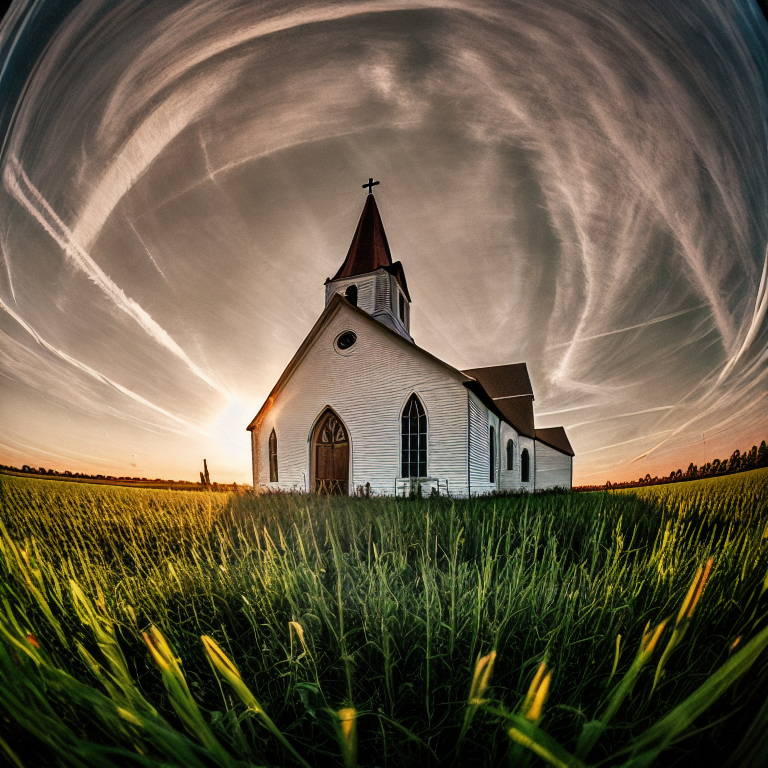

In [ ]:
image

In [ ]:
# Prompt 2
#prompt = """
#dreamlikeart style, a grungy woman with vibrant rainbow hair, traveling between surreal dimensions, dynamic action pose, joyful expression, glowing eyes, extreme torn and buggy jeans, cinematic lighting, magical energy swirls around her, ethereal background with portals, highly detailed, hyperrealism, concept art quality, fantasy realism, ultra sharp, 8k resolution

# image = pipe(prompt).images[0]

In [ ]:
'''prompt = """
dreamlikeart style, a grungy woman with vibrant rainbow hair, athletic build, slim waist, standing on one foot in a dynamic mid-air twist, arms extended forward, joyful expression, glowing purple eyes, pierced eyebrow, wearing a ripped leather jacket and extreme torn buggy jeans, heavy boots, magical energy swirling around her hands, cinematic backlight, vivid rainbow trail from hair movement, surrounded by glowing dimensional portals, ethereal mist, high detail, fantasy realism, hyperrealism, 8k resolution, ultra sharp, concept art
"""
image = pipe(prompt).images[0]
image'''

'prompt = """\ndreamlikeart style, a grungy woman with vibrant rainbow hair, athletic build, slim waist, standing on one foot in a dynamic mid-air twist, arms extended forward, joyful expression, glowing purple eyes, pierced eyebrow, wearing a ripped leather jacket and extreme torn buggy jeans, heavy boots, magical energy swirling around her hands, cinematic backlight, vivid rainbow trail from hair movement, surrounded by glowing dimensional portals, ethereal mist, high detail, fantasy realism, hyperrealism, 8k resolution, ultra sharp, concept art\n"""\nimage = pipe(prompt).images[0]\nimage'

## Working with Stable Diffuser Parameters

- Negative Prompting
- num_inference_steps
- height
- weigth
- num_imges_per_prompt

In [ ]:
def generate_image(pipe, prompt, params):  # the fn will take pipeline object
  img = pipe(prompt, **params).images

  # Params configuration
  num_img = len(img)
  if num_img > 1:
    fig, ax = plt.subplots(nrows=1, ncols=num_img)
    for i in range(num_img):
      ax[i].imshow(img[i])
      ax[i].axis("off")

  # Generate Image
  else:
    fig = plt.figure()
    plt.imshow(img[0])
    plt.axis("off")
  plt.tight_layout()



In [ ]:
# Define another prompt
prompt = "photo, a church in the middle of a field of crops, bright cinematic lighting, gopro, fisheye lens"
params = {}

  0%|          | 0/50 [00:00<?, ?it/s]

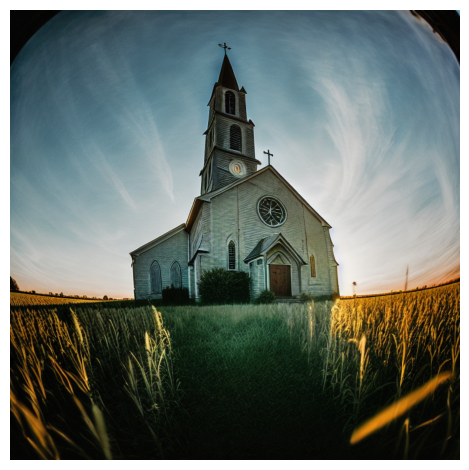

In [ ]:
# Generate image by calling function
generate_image(pipe, prompt, params)

### Params Customization

  0%|          | 0/50 [00:00<?, ?it/s]

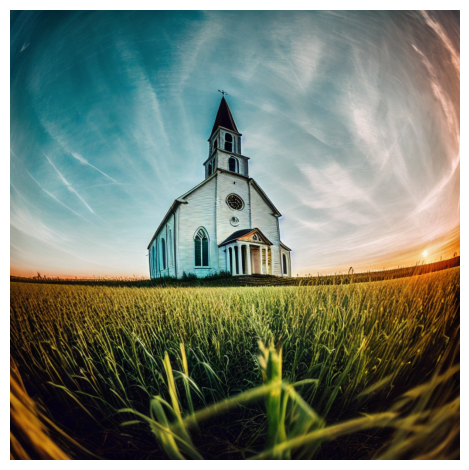

In [ ]:
# We can define some params here
params = {"num_inference_steps": 50}  # num_inference define best one out of 50 gene

generate_image(pipe, prompt, params)

  0%|          | 0/50 [00:00<?, ?it/s]

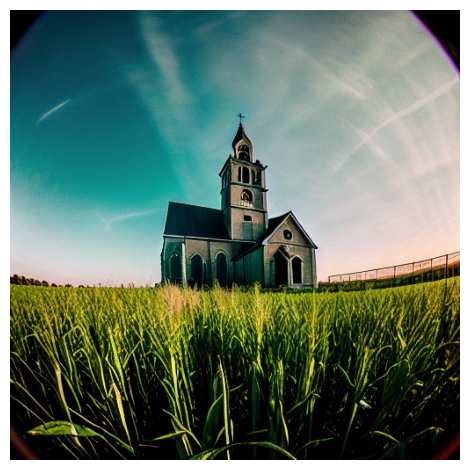

In [ ]:
# Height width- Parameter Tunning
params = {"num_inference_steps": 50, "height": 512, "width": 512}

generate_image(pipe, prompt, params)


  0%|          | 0/100 [00:00<?, ?it/s]

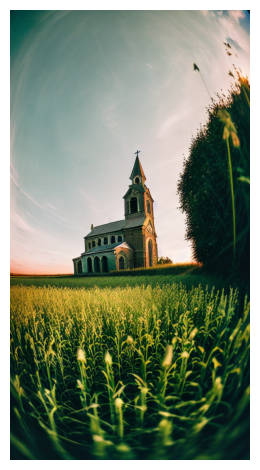

In [ ]:
# Height width- Parameter Tunning
params = {"num_inference_steps": 100, "width": 512, "height": int(1.5*640)}

generate_image(pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

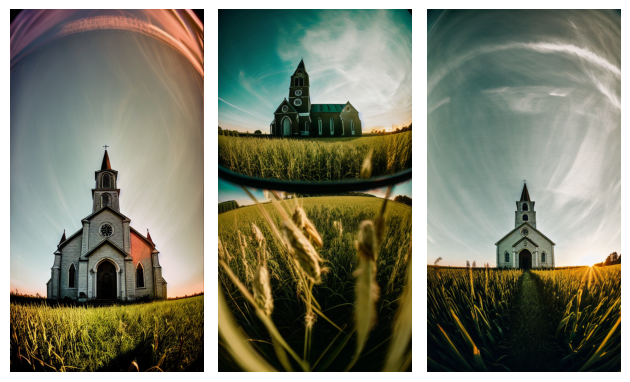

In [ ]:
# Param: num_images_per_prompt
params = {"num_inference_steps": 100, "width": 512, "height": int(1.5*640), "num_images_per_prompt": 3} #

generate_image(pipe, prompt, params)  # Return best 3 out of 100 image

# Text To Speech Generation

In [ ]:
from transformers import pipeline # for text operation

In [ ]:
sample_text = "Python is a high-level, general-purpose programming language known for its readability and versatility. It's widely used in web development, data science, machine learning, and automation, and is appreciated for its simple syntax and large standard library. "

pipe = pipeline("text-to-speech", model = "suno/bark-small", device="cuda") # what to perform, model name & confirm device
speech = pipe(sample_text)

config.json:   0%|          | 0.00/8.80k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/4.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/353 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [ ]:
# Show output - it will return sound wave number, sampling rate : define the speed of the output sound
speech

{'audio': array([[ 0.01585461,  0.0164561 ,  0.01611312, ..., -0.00182377,
         -0.00056282,  0.00096308]], dtype=float32),
 'sampling_rate': 24000}

In [ ]:
from IPython.display import Audio
Audio(speech["audio"], rate=speech["sampling_rate"])

# Q&A and Facts

**Question1: How Mutlimodel Built?**
its built by below two ways:
1. Text Model Architecture(Language Model)
2. Diffusion Model (CV Model)

**Q2: Why Accelarate ?**
- For using GPU

**Q3: Why StableTransforDiffuer?**
- For Multi model, we can do by transformer which required extra codes, but diffusionpipeline do all at time for Language Model


### Facts

- Colab has builtIn PyTorch installed no need to installed seperately
- `nvidia-smi` Run in command line to check NVDIA GPU wherther insalled or not

**Pipeline Define**

- `pipe = StableDiffusionPipeline.from_pretrained(model_name, torch_dtype=torch.float16, use_safetensors=True)` : pixel value will be loaded in float16, and in GPU(cuda). why `use_safetensors`: since you are using `GPU`
- the pipeline will download the model from internate/hugging face to your machine

`image = pipe(prompt).images[0]` :
- This code is using a text-to-image pipeline, likely from a library like Diffusers (Hugging Face). The `pipe(prompt)` function generates an object (usually a `StableDiffusionPipelineOutput`) which contains:
- `.images`: is a list (even if only one image is generated)
- `[0]`: gets the first image from that list

**Why index 0?**
**Because:**

- The pipeline returns results like: `images = [<PIL.Image>, <PIL.Image>, ...]`
- If you only request 1 image, it’s stored as the first item in the list
- So, `.images[0]`is how you retrieve the only or first image

# Article

Dreamlike Photoreal 2.0 is a highly regarded AI image generation model based on Stable Diffusion, specifically fine-tuned for photorealism. It’s designed to create lifelike, high-quality images that closely resemble real photographs, unlike many other models that produce artistic or surreal visuals.



### Application of Text-to-Speech

Text-to-Speech (TTS) using Generative AI has evolved significantly, enabling natural, expressive, and highly customizable synthetic voices. Here are some key applications of TTS with Generative AI:


🔊 1. Voice Assistants & Chatbots
  - Used in Siri, Alexa, Google Assistant, and conversational AI bots.

  - Provides human-like responses that enhance user experience and accessibility.

🧑‍🎓 2. Education & E-Learning
  - Creates audiobooks, course content, language learning tools.

  - Helps visually impaired learners and supports multilingual voice content generation.

   3. Customer Service & Call Centers
- Automates responses with lifelike voice for IVR systems or outbound calls.

- Reduces operational costs and improves 24/7 service availability.

🎮 4. Gaming & Virtual Worlds
- Used in NPC dialogue, narration, or dynamic storytelling.

- Enables character customization with different voice personalities.

🎥 5. Media, Audiobooks & Content Creation
- Converts blogs, scripts, or articles into audio or video narration.

- Helps YouTubers and content creators produce voiceovers without recording.

🏥 6. Healthcare
- Assists patients with reading medical instructions.

- Supports therapeutic applications (e.g., speech training, mental health AI assistants).

🧓 7. Accessibility
 - Empowers visually impaired or dyslexic users to consume written content.

 - Also used in assistive tech for elderly or speech-disabled individuals.

🌍 8. Localization & Multilingual Support
 - Generates natural speech in multiple languages or accents.

 - Useful for global apps, dubbing, and inclusive experiences.

🧠 9. Personalized Voice Cloning
 - For content creators, influencers, or brands to use their unique voice at scale.

 - Can also recreate voices for legacy media or deceased individuals (with consent).

